In [2]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


# testing functions

In [4]:
def equally_spaced_positions(N,d):
    if N % 2 == 1:
        positions = np.arange(-(N//2), N//2 + 1) * d
    else:
        # for even N, center between two ions
        positions = (np.arange(-N/2 + 0.5, N/2 + 0.5)) * d
    positions_list = positions.tolist()
    return positions_list

In [126]:
def ion_force_quartic(positions, N, k4, omega_rf_axial):
    """
    Calculate force on each ion.
    
    Inputs:
    -----------
    positions : array-like
        Position of each ion (length N)
    N : int
        Number of ions
    k4 : float
        Quartic interaction coefficient
    omega_rf_axial : float
        Axial trapping frequency from rf potential (2*pi*Hz)
    
    Returns:
    --------
    force_list : list
        Force on each ion (length N)
    """
    x = np.array(positions)
    N = len(x)
    A = 0.5 * m * omega_rf_axial**2
    B = (e**2) / (4 * pi * eps0)
    C = k4

    return [2*A*(x[m]) + 4*C * (x[m]**3) 
            - sum([B * (x[m] - x[n]) / (abs(x[m] - x[n])**3) for n in range(m) if x[m] != x[n]])  # Avoid division by zero
            + sum([B * (x[m] - x[n]) / (abs(x[m] - x[n])**3) for n in range(m+1, N) if x[m] != x[n]])  # Avoid division by zero
           
            for m in range(N)]


N = 15
k4 = 0.00177
omega_rf_axial = 150e3*2*pi
estimated_extreme = 0.481*N**0.765
x0 = np.linspace(-estimated_extreme, estimated_extreme, N)

ueq_test = fsolve(ion_force_quartic, x0, args=(N, k4, omega_rf_axial))
diff_list = []
for x, y in zip(ueq_test[0::], ueq_test[1::]):
    diff_list.append(y-x)
diff_list

/Users/ritika/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


[5.231334134260145e-06,
 4.323839194694244e-06,
 4.72025407683626e-06,
 3.44286201413891e-06,
 7.1912297104941415e-06,
 4.469411295911118e-06,
 -7.2870498116343415e-06,
 1.781096366938332e-05,
 3.011792890101129e-06,
 -7.898670131382756e-06,
 9.874248939254035e-06,
 2.2413323608826758e-06,
 3.211509994864699e-06,
 1.7354252790722454e-06]

# trying functions

### I am assuming the potential is quartic in the axial direction and magically creates equally spaced ions.  In the radial direction, it is magically quadratic and my radial Hessian is analytically unchanged, only the equilibrium positions are changed. 

Make a function that generates equally spaced ions for whatever N I want, and then use that function in all of my other functions.  see what else in the pipeline needs to change to accomodate this change.

1. given some distance d, make a list that puts the center ion at z=0 and spaces the remaining N ions equally spaced from the center ion
2. go through the pipeline to put in equlibrium positions as a function input
3. run functions

In [127]:
N = range(2, 8)
w_rf_a = 0.125e6*2*np.pi
w_rf_r = 4e6*2*np.pi
f_rf_r = w_rf_r/(2*pi)
f_rf_a = w_rf_a/(2*pi)

tweezed_ion = [0]
P_opt = [100e-3]
w0 = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt[0],w0)

In [128]:
ueq_equally_spaced = {
    N: equally_spaced_positions(
        N,
        ion_spacing(N, w_rf_a)[0][1] - ion_spacing(N, w_rf_a)[0][0],
    )
    for N in N
}

In [129]:
P_opt = [50e-3]
w0 = 1e-6
f_rf_r = 3e6


results_test_check = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq_equally_spaced,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_test_check.append((Ni, winners))

untweezed_results = []

for Ni in range(2,8):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq_equally_spaced,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))

In [130]:
results_test_check[-2]

(6,
 [(2,
   (2, 5, 0, 3, 1, 4),
   0.03449893824733369,
   [0.05],
   array([-0.04488629,  0.04011182,  0.04466256,  0.03449894, -0.04625432,
           0.03667394])),
  (3,
   (3, 0, 5, 2, 4, 1),
   -0.03449893824733798,
   [0.05],
   array([-0.04488629, -0.04011182,  0.04466256, -0.03449894, -0.04625432,
           0.03667394]))])

In [131]:
untweezed_results

[(2,
  [(nan,
    (1, 0),
    0.03956930721333248,
    [0.05],
    array([ 0.03956931, -0.0395865 ]))]),
 (3,
  [(nan,
    (2, 0, 1),
    0.032308204049365866,
    [0.05],
    array([ 0.0323082 , -0.0395865 , -0.04573842]))]),
 (4,
  [(nan,
    (0, 3, 1, 2),
    0.027979725457412907,
    [0.05],
    array([0.02797973, 0.03692342, 0.02800862, 0.03696761])),
   (nan,
    (0, 3, 2, 1),
    0.027979725457412907,
    [0.05],
    array([ 0.02797973,  0.03692342,  0.02800862, -0.03696761]))]),
 (5,
  [(nan,
    (0, 4, 2, 1, 3),
    0.025025827245817756,
    [0.05],
    array([ 0.02502583, -0.03420951, -0.03380274,  0.03425182,  0.02817187])),
   (nan,
    (0, 4, 2, 3, 1),
    0.025025827245817756,
    [0.05],
    array([ 0.02502583, -0.03420951, -0.03380274, -0.03425182,  0.02817187]))]),
 (6,
  [(nan,
    (5, 0, 2, 1, 4, 3),
    -0.022845350171271244,
    [0.05],
    array([-0.02284535, -0.03183427,  0.0271274 ,  0.02476363, -0.03233192,
           -0.03254412])),
   (nan,
    (5, 0, 2, 4, 1

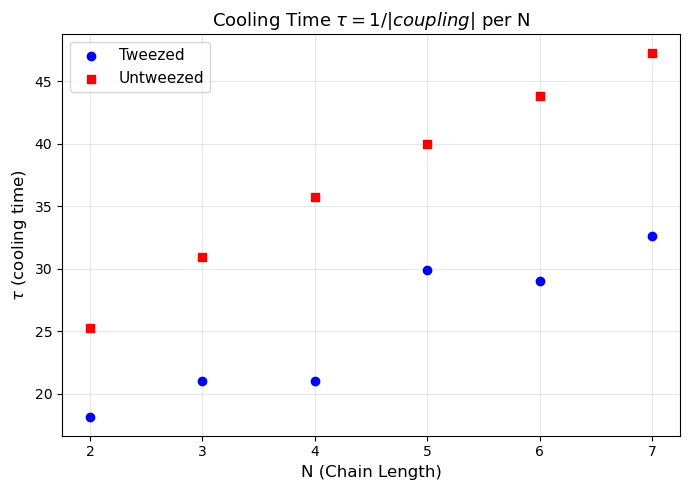

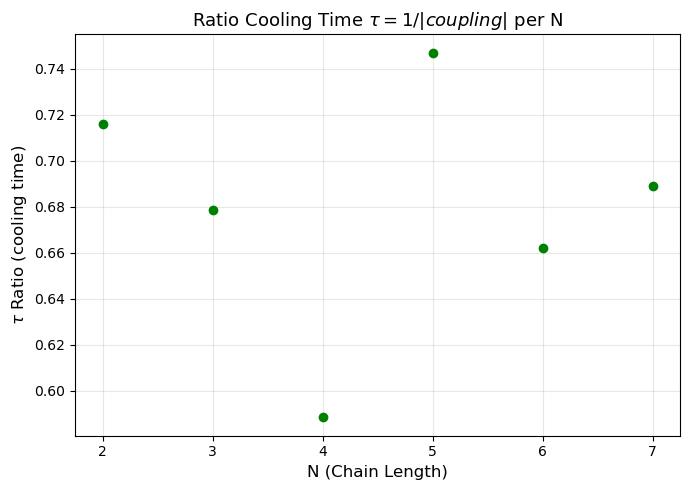

In [132]:
tweezed_data = {}  # {N: score}

for N_val, winners in results_test_check:
    if not winners:
        continue
    
    # Just take the first winner (it's already the best)
    win = winners[0]
    
    # Extract tweezed ion directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)):
        tweezed_ion = win[0][0]
    else:
        tweezed_ion = win[0]
    
    if tweezed_ion is None:
        continue  # Skip untweezed
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        tweezed_data[N_val] = abs(score)

# --- Extract untweezed winning scores (same approach) ---
untweezed_data = {}  # {N: score}

for N_val, winners in untweezed_results:
    if not winners:
        continue
    
    # Just take the first winner
    win = winners[0]
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        untweezed_data[N_val] = abs(score)

# --- Prepare arrays for plotting ---
N_tweezed = sorted(tweezed_data.keys())
scores_tweezed = [tweezed_data[N] for N in N_tweezed]

N_untweezed = sorted(untweezed_data.keys())
scores_untweezed = [untweezed_data[N] for N in N_untweezed]

# Convert to 1/score (tau) for better visibility
tau_tweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_tweezed])
tau_untweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_untweezed])

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed, marker='o', color='blue', 
            label='Tweezed', zorder=3)
ax.scatter(N_untweezed, tau_untweezed, marker='s', color='red', 
            label='Untweezed', zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ (cooling time)', fontsize=12)
ax.set_title(r'Cooling Time $\tau = 1/|coupling|$ per N', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed/tau_untweezed, marker='o', color='green', 
            zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ Ratio (cooling time)', fontsize=12)
ax.set_title(r'Ratio Cooling Time $\tau = 1/|coupling|$ per N', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Power Sweep


In [133]:
N_values = np.arange(2,8)
w0 = 1e-6
P_list = np.linspace(1e-6,5,50)  # optical powers from 10 mW to 1 W
# --- Run power sweep using your tweezed-only function ---
power_results = [ [] for _ in N_values]  # List of lists to hold winners for each N
for N in N_values:
    for P in P_list:
        winners = run_optimal_mode_selection_tweezed_only(
            omega_tweezer,
            linewidths,
            omega_res,
            m,
            mode_calc_r,
            N,
            f_rf_r,
            ueq_equally_spaced,
            P,
            w0,
            max_tweezed=1
        )
        power_results[N-2].append(winners)


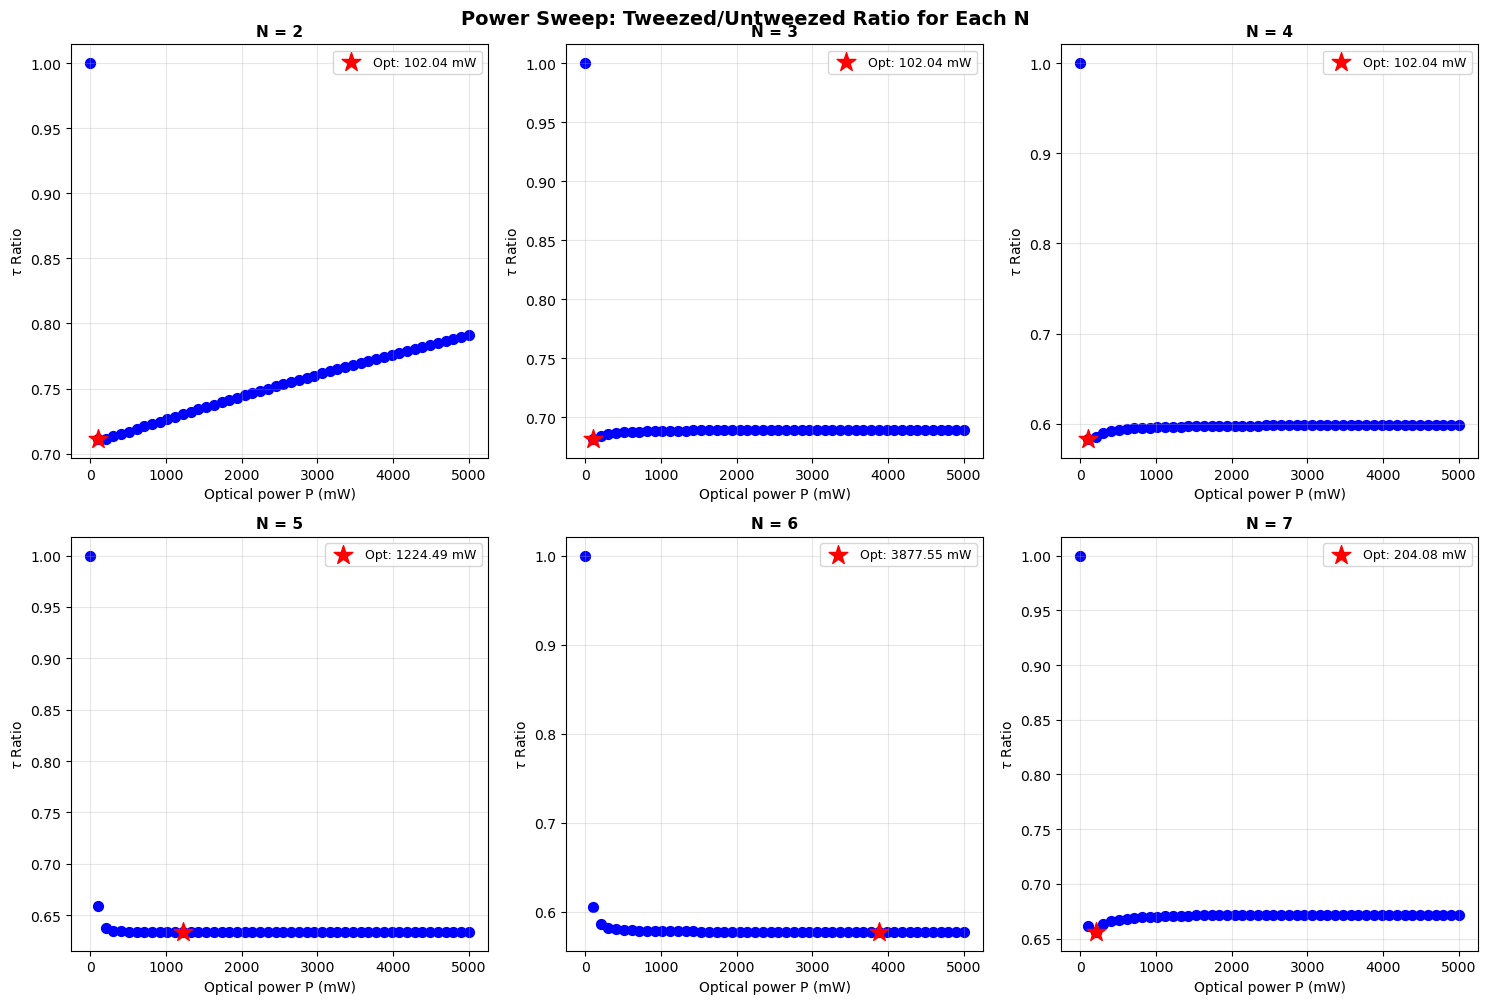


Optimal Powers Summary:
N = 2: P_opt = 1.020418e-01 W = 102.0418 mW,  Ratio = 0.7110
N = 3: P_opt = 1.020418e-01 W = 102.0418 mW,  Ratio = 0.6813
N = 4: P_opt = 1.020418e-01 W = 102.0418 mW,  Ratio = 0.5826
N = 5: P_opt = 1.224491e+00 W = 1224.4906 mW,  Ratio = 0.6337
N = 6: P_opt = 3.877551e+00 W = 3877.5512 mW,  Ratio = 0.5775
N = 7: P_opt = 2.040826e-01 W = 204.0826 mW,  Ratio = 0.6561


In [134]:
# --- Extract and plot for each N ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

optimal_powers_W = []
optimal_powers_mW = []
optimal_ratios = []

for Ni in range(2,8):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq_equally_spaced,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))
untweezed_winners = [abs(winners[0][2]) for Ni, winners in untweezed_results]

for idx, N in enumerate(N_values):
    x_tweezed = []
    y_tweezed = []
    
    # Extract scores from power_results for this N
    for P_opt, winners in zip(P_list, power_results[N-2]):
        if not winners:
            continue
        winner = winners[0]
        
        if len(winner) >= 3:
            tweezed_ion = winner[0]
            score = winner[2]
        else:
            continue
        
        if tweezed_ion is None:
            continue
        
        x_tweezed.append(P_opt)
        y_tweezed.append(abs(score))
    
    x_tweezed = np.array(x_tweezed)
    y_tweezed = np.array(y_tweezed)
    
    untweezed_ref = untweezed_winners[N-2]
    
    if len(y_tweezed) > 0:
        ratio = untweezed_ref / y_tweezed
        opt_idx = np.argmin(ratio)
        
        opt_power_W = x_tweezed[opt_idx]
        opt_power_mW = opt_power_W * 1e3
        opt_ratio = ratio[opt_idx]
        
        optimal_powers_W.append(opt_power_W)
        optimal_powers_mW.append(opt_power_mW)
        optimal_ratios.append(opt_ratio)
        
        # Plot
        axes[idx].scatter(x_tweezed * 1e3, ratio, marker='o', color='blue', s=50)
        axes[idx].set_xlabel("Optical power P (mW)", fontsize=10)
        axes[idx].set_ylabel(r"$\tau$ Ratio", fontsize=10)
        axes[idx].set_title(f"N = {N}", fontsize=11, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        
        axes[idx].scatter(opt_power_mW, opt_ratio, color='red', s=200, marker='*', 
                         zorder=5, label=f'Opt: {opt_power_mW:.2f} mW')
        axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Power Sweep: Tweezed/Untweezed Ratio for Each N", 
             fontsize=14, fontweight='bold', y=1.00)
plt.show()

# --- Print summary (AFTER loop completes) ---
optimal_powers_W = np.array(optimal_powers_W)
optimal_powers_mW = np.array(optimal_powers_mW)
optimal_ratios = np.array(optimal_ratios)

print("\nOptimal Powers Summary:")
print("=" * 60)
for N, P_W, P_mW, ratio in zip(N_values, optimal_powers_W, optimal_powers_mW, optimal_ratios):
    print(f"N = {N}: P_opt = {P_W:.6e} W = {P_mW:.4f} mW,  Ratio = {ratio:.4f}")
print("=" * 60)

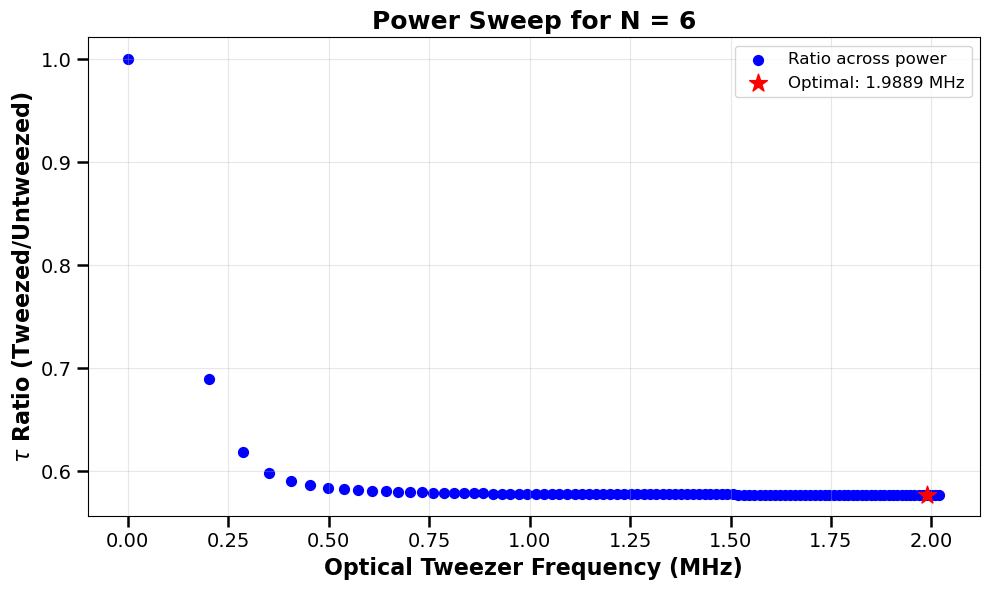


Optimal settings for N = 6:
P_opt = 3.878788e+00 W = 3878.7879 mW
Optimal optical tweezer frequency = 1.988903 MHz
Ratio = 0.5775


In [135]:
# Plot power sweep for N=6 alone

N = 6
w0 = 1e-6
P_list = np.linspace(1e-6, 4, 100)  # optical powers

# Ensure equilibrium dictionary contains N=6
f_rf_a_local = globals().get('f_rf_a', 0.125e6)
w_rf_a_local = 2 * pi * f_rf_a_local
spacing_local = ion_spacing(N, w_rf_a_local)[0][1] - ion_spacing(N, w_rf_a_local)[0][0]
ueq_dict_local = {N: equally_spaced_positions(N, spacing_local)}

# Run power sweep for N=6
power_results_N6 = []
for P in P_list:
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq_dict_local,
        P,
        w0,
        max_tweezed=1
    )
    power_results_N6.append(winners)

# Get untweezed reference for N=6
untweezed_winners_N6 = untweezed_winners[N-2]

# Extract data
x_tweezed = []
y_tweezed = []
freqs_tweezed_Hz = []

for P_val, winners in zip(P_list, power_results_N6):
    if not winners:
        continue
    winner = winners[0]

    if len(winner) >= 3:
        tweezed_ion = winner[0]
        score = winner[2]
    else:
        continue

    if tweezed_ion is None:
        continue

    x_tweezed.append(P_val)
    y_tweezed.append(abs(score))
    freqs_tweezed_Hz.append(
        omega_tweezer_r(potential(omega_tweezer, linewidths, omega_res, P_val, w0), w0, m)
    )

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)
freqs_tweezed_Hz = np.array(freqs_tweezed_Hz)

# Calculate ratio
ratio = untweezed_winners_N6 / y_tweezed
opt_idx = np.argmin(ratio)

opt_power_W = x_tweezed[opt_idx]
opt_power_mW = opt_power_W * 1e3
opt_ratio = ratio[opt_idx]
opt_tweezer_freq_MHz = freqs_tweezed_Hz[opt_idx] / (2.0 * pi * 1e6)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(freqs_tweezed_Hz / (2.0 * pi * 1e6), ratio, marker='o', color='blue', s=50, label='Ratio across power')
ax.scatter(opt_tweezer_freq_MHz, opt_ratio, color='red', s=180, marker='*', zorder=5,
           label=f'Optimal: {opt_tweezer_freq_MHz:.4f} MHz')
ax.set_xlabel("Optical Tweezer Frequency (MHz)", fontsize=16, fontweight='bold')
ax.set_ylabel(r"$\tau$ Ratio (Tweezed/Untweezed)", fontsize=16, fontweight='bold')
ax.set_title(f"Power Sweep for N = {N}", fontsize=18, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=14, length=8, width=1.8)

plt.tight_layout()
plt.show()

print(f"\nOptimal settings for N = {N}:")
print("=" * 60)
print(f"P_opt = {opt_power_W:.6e} W = {opt_power_mW:.4f} mW")
print(f"Optimal optical tweezer frequency = {opt_tweezer_freq_MHz:.6f} MHz")
print(f"Ratio = {opt_ratio:.4f}")
print("=" * 60)

In [145]:
# Show winner for N=6 at the optimal power found earlier
N = 6
P_opt_N6 = float(optimal_powers_W[N-2])

winners_N6_untweezed = run_optimal_mode_selection_untweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    ueq_equally_spaced,
    P_opt_N6,
    w0
)
winners_N6 = run_optimal_mode_selection_tweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    ueq_equally_spaced,
    P_opt_N6,
    w0)

if winners_N6:
    best = winners_N6[0]
    print("N =", N, "P_opt (W) =", P_opt_N6)
    print("Winner (best):", best)
else:
    print("No winner returned for N =", N, "at P =", P_opt_N6)

KeyError: 6

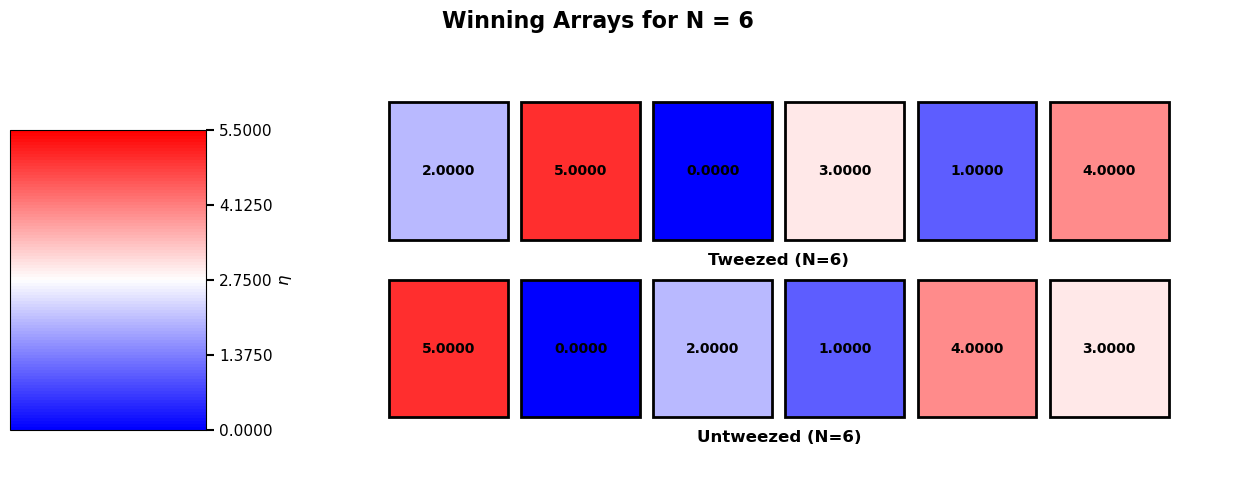

N=6 comparison plotted at P = 3.878788e+00 W


In [147]:
# Plot winning arrays for N=6 (tweezed vs untweezed), stacked
N = 6

# Use N=6 local equilibrium dict to avoid KeyError if global dict was overwritten
f_rf_a_local = globals().get('f_rf_a', 0.125e6)
w_rf_a_local = 2 * pi * f_rf_a_local
spacing_local = ion_spacing(N, w_rf_a_local)[0][1] - ion_spacing(N, w_rf_a_local)[0][0]
ueq_dict_local = {N: equally_spaced_positions(N, spacing_local)}

# Pick power for N=6 (prefer the last N=6 sweep result if present)
if 'opt_power_W' in globals():
    P_opt_N6 = float(opt_power_W)
elif 'optimal_powers_W' in globals() and len(optimal_powers_W) >= (N - 1):
    P_opt_N6 = float(optimal_powers_W[N - 2])
else:
    P_opt_N6 = 1e-3

winners_N6_t = run_optimal_mode_selection_tweezed_only(
    omega_tweezer, linewidths, omega_res, m, mode_calc_r,
    N, f_rf_r, ueq_dict_local, P_opt_N6, w0, max_tweezed=1
)
winners_N6_u = run_optimal_mode_selection_untweezed_only(
    omega_tweezer, linewidths, omega_res, m, mode_calc_r,
    N, f_rf_r, ueq_dict_local, P_opt_N6, w0
)

def extract_winner_array(winners, N_expected):
    if not winners:
        return None
    best = winners[0]

    # Common direct locations first
    if isinstance(best, (list, tuple)):
        for idx in (1, 2, 0):
            if idx < len(best):
                try:
                    arr = np.asarray(best[idx], dtype=float)
                    if arr.ndim == 1 and arr.size == N_expected:
                        return arr
                except Exception:
                    pass

    # Recursive fallback
    found = []
    def walk(obj):
        if isinstance(obj, np.ndarray):
            if obj.ndim == 1 and obj.size == N_expected and np.issubdtype(obj.dtype, np.number):
                found.append(obj.astype(float))
            return
        if isinstance(obj, (list, tuple)):
            try:
                arr = np.asarray(obj, dtype=float)
                if arr.ndim == 1 and arr.size == N_expected:
                    found.append(arr)
            except Exception:
                pass
            for item in obj:
                walk(item)

    walk(best)
    return found[0] if found else None

vals_tweezed = extract_winner_array(winners_N6_t, N)
vals_untweezed = extract_winner_array(winners_N6_u, N)

if vals_tweezed is None or vals_untweezed is None:
    print('Could not extract one of the winner arrays for N=6.')
else:
    # Shared color scaling across both rows
    all_vals = np.concatenate([vals_tweezed, vals_untweezed])
    vmax = 1.10 * np.max(all_vals)
    vmin = 1.10 * np.min(all_vals)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # Diverging colormap: red (-) -> white (0) -> blue (+)
    colors_div = ['red', 'white', 'blue']
    cmap_div = mcolors.LinearSegmentedColormap.from_list('red_white_blue', colors_div, N=100)
    cmap_div_r = cmap_div.reversed()

    fig = plt.figure(figsize=(14, 6))

    # Colorbar
    cax_colorbar = fig.add_axes([0.08, 0.25, 0.14, 0.5])
    cb = mcolorbar.ColorbarBase(
        cax_colorbar, cmap=cmap_div_r, norm=norm, orientation='vertical'
    )
    cb.set_label(r'$\eta$', fontsize=12, fontweight='bold')
    ticks = np.linspace(vmin, vmax, 5)
    cb.set_ticks(ticks)
    cb.set_ticklabels([f'{t:.4f}' for t in ticks])
    cb.ax.tick_params(labelsize=11, length=6, width=1.5)

    # Rectangles axis (two rows)
    ax_rects = fig.add_axes([0.28, 0.15, 0.67, 0.7])
    ax_rects.set_xlim(-0.7, N + 0.4)
    ax_rects.set_ylim(-0.2, 2.4)
    ax_rects.axis('off')

    rect_width = 0.9
    rect_height = 0.85
    y_top = 1.35       # Tweezed row
    y_bottom = 0.25    # Untweezed row

    for i, val in enumerate(vals_tweezed):
        x_pos = i + 0.05
        color = cmap_div_r(norm(val))
        rect = plt.Rectangle((x_pos, y_top), rect_width, rect_height,
                             facecolor=color, edgecolor='black', linewidth=2)
        ax_rects.add_patch(rect)
        ax_rects.text(x_pos + rect_width/2, y_top + rect_height/2,
                      f'{val:.4f}', ha='center', va='center',
                      fontsize=10, fontweight='bold', color='black')

    for i, val in enumerate(vals_untweezed):
        x_pos = i + 0.05
        color = cmap_div_r(norm(val))
        rect = plt.Rectangle((x_pos, y_bottom), rect_width, rect_height,
                             facecolor=color, edgecolor='black', linewidth=2)
        ax_rects.add_patch(rect)
        ax_rects.text(x_pos + rect_width/2, y_bottom + rect_height/2,
                      f'{val:.4f}', ha='center', va='center',
                      fontsize=10, fontweight='bold', color='black')

    # Row labels underneath each set of rectangles
    x_center = N / 2
    ax_rects.text(x_center, y_top - 0.08, 'Tweezed (N=6)',
                  fontsize=12, fontweight='bold', ha='center', va='top')
    ax_rects.text(x_center, y_bottom - 0.08, 'Untweezed (N=6)',
                  fontsize=12, fontweight='bold', ha='center', va='top')

    fig.suptitle('Winning Arrays for N = 6', fontsize=16, fontweight='bold', y=0.95)
    plt.show()

    print(f'N=6 comparison plotted at P = {P_opt_N6:.6e} W')

In [138]:
P_opt = optimal_powers_W 
w0 = 1e-6
f_rf_r = 3e6
f_rf_a= 0.125e6

results_test_check = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq_equally_spaced,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_test_check.append((Ni, winners))

untweezed_results = []

for Ni in range(2,8):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq_equally_spaced,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))

untweezed_winners = [untweezed_results[i-2][1][0][2] for i in range(2,8)]

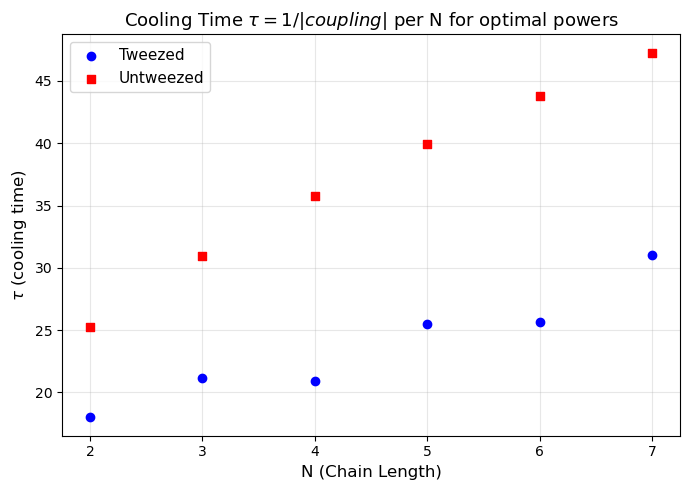

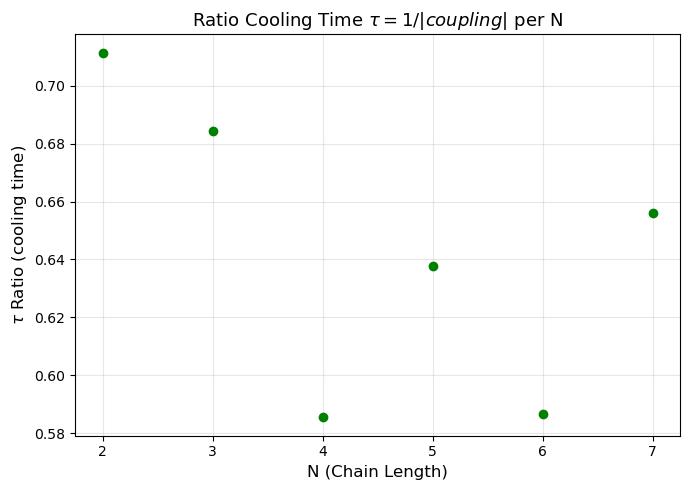

In [139]:
tweezed_data = {}  # {N: score}

for N_val, winners in results_test_check:
    if not winners:
        continue
    
    # Just take the first winner (it's already the best)
    win = winners[0]
    
    # Extract tweezed ion directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)):
        tweezed_ion = win[0][0]
    else:
        tweezed_ion = win[0]
    
    if tweezed_ion is None:
        continue  # Skip untweezed
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        tweezed_data[N_val] = abs(score)

# --- Extract untweezed winning scores (same approach) ---
untweezed_data = {}  # {N: score}

for N_val, winners in untweezed_results:
    if not winners:
        continue
    
    # Just take the first winner
    win = winners[0]
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        untweezed_data[N_val] = abs(score)

# --- Prepare arrays for plotting ---
N_tweezed = sorted(tweezed_data.keys())
scores_tweezed = [tweezed_data[N] for N in N_tweezed]

N_untweezed = sorted(untweezed_data.keys())
scores_untweezed = [untweezed_data[N] for N in N_untweezed]

# Convert to 1/score (tau) for better visibility
tau_tweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_tweezed])
tau_untweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_untweezed])

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed, marker='o', color='blue', 
            label='Tweezed', zorder=3)
ax.scatter(N_untweezed, tau_untweezed, marker='s', color='red', 
            label='Untweezed', zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ (cooling time)', fontsize=12)
ax.set_title(r'Cooling Time $\tau = 1/|coupling|$ per N for optimal powers', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed/tau_untweezed, marker='o', color='green', 
            zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ Ratio (cooling time)', fontsize=12)
ax.set_title(r'Ratio Cooling Time $\tau = 1/|coupling|$ per N', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#midcircuit

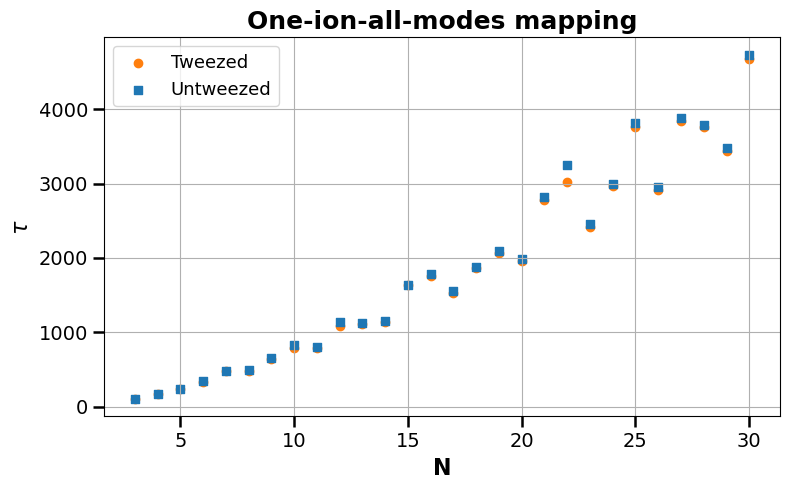

In [140]:
N = np.arange(3,4)
P = [1e-3]
w0 = 1e-6
f_rf_r = 3e6
f_rf_a = 0.125e6

dfs = []
many_N = []

ueq_equally_spaced = {N:equally_spaced_positions(N, ion_spacing(N,w_rf_a)[0][1]-ion_spacing(N,w_rf_a)[0][0]) for N in range(3, 31)}

for N in range(3, 31):
    test_loop = midcircuit_modes(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq_equally_spaced,
        P,
        w0,
    )
    many_N.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs.append(df)

dfs_untweezed = []
many_N_untweezed = []

for N in range(3, 31):
    test_loop = midcircuit_modes_untweezed(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq_equally_spaced,
        P,
        w0,
    )
    many_N_untweezed.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs_untweezed.append(df)
# combine per-N DataFrames if not already done

combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

fig, ax = plt.subplots(figsize=(8, 5))
if Ns_t.size:
    ax.scatter(Ns_t, vals_t, marker='o', color='C1', label='Tweezed')
if Ns_u.size:
    ax.scatter(Ns_u, vals_u, marker='s', color='C0', label='Untweezed')
ax.set_xlabel("N", fontsize=16, fontweight='bold')
ax.set_ylabel(r"$\tau$", fontsize=16, fontweight='bold')
ax.set_title("One-ion-all-modes mapping", fontsize=18, fontweight='bold')
ax.grid(True)
ax.legend(fontsize=13)
ax.tick_params(axis='both', which='major', labelsize=14, length=8, width=1.8)
plt.tight_layout()
plt.show()

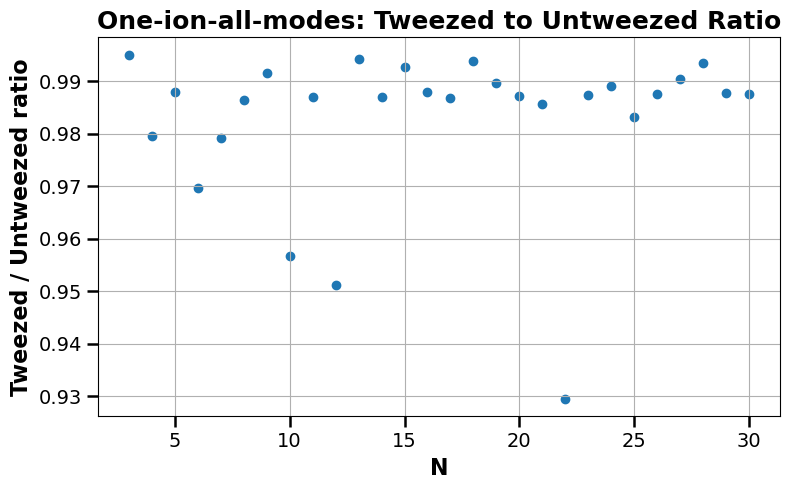

In [141]:
# Calculate ratio of tweezed to untweezed
common_N = sorted(set(Ns_t).intersection(set(Ns_u)))
ratio_vals = []

for N in common_N:
    idx_t = np.where(Ns_t == N)[0]
    idx_u = np.where(Ns_u == N)[0]
    if len(idx_t) > 0 and len(idx_u) > 0:
        val_t = vals_t[idx_t[0]]
        val_u = vals_u[idx_u[0]]
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = val_t / val_u if val_u != 0 else np.nan
        ratio_vals.append(ratio)
    else:
        ratio_vals.append(np.nan)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(common_N, ratio_vals, marker='o')
ax.set_xlabel("N", fontsize=16, fontweight='bold')
ax.set_ylabel(r"Tweezed / Untweezed ratio", fontsize=16, fontweight='bold')
ax.set_title("One-ion-all-modes: Tweezed to Untweezed Ratio", fontsize=18, fontweight='bold')
ax.grid(True)
#ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, label='Ratio = 1')
#ax.legend()
ax.tick_params(axis='both', which='major', labelsize=14, length=8, width=1.8)
plt.tight_layout()
plt.show()

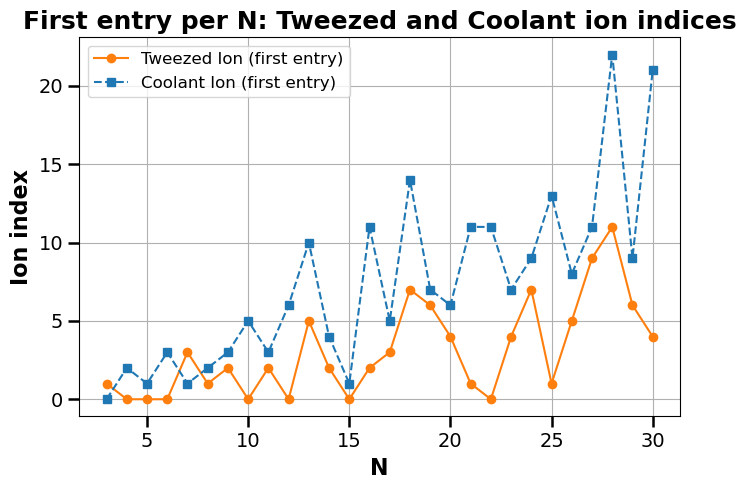

In [142]:

def _get_df_for_N(many, combined, N):
    if isinstance(many, list):
        for n, item in many:
            if n == N:
                if isinstance(item, pd.DataFrame):
                    return item.copy().reset_index(drop=True)
                return None
    if isinstance(combined, pd.DataFrame) and not combined.empty:
        tmp = combined[combined['N'] == N]
        if not tmp.empty:
            return tmp.copy().reset_index(drop=True)
    return None

many = globals().get('many_N')
combined = globals().get('combined_df')

if isinstance(many, list) and many:
    Ns = sorted({n for n, _ in many})
elif isinstance(combined, pd.DataFrame) and not combined.empty and 'N' in combined.columns:
    Ns = sorted(combined['N'].unique())
else:
    Ns = list(range(3, 30))

Ns = list(Ns)
first_t = []
first_c = []
second_t = []
second_c = []

for N in Ns:
    df = _get_df_for_N(many, combined, N)
    if df is None or df.empty:
        first_t.append(np.nan); first_c.append(np.nan)
        second_t.append(np.nan); second_c.append(np.nan)
        continue

    def safe_int(x):
        try:
            return int(x)
        except Exception:
            try:
                return int(float(x))
            except Exception:
                return np.nan

    # first entry (row 0)
    r0 = df.iloc[0]
    first_t.append(safe_int(r0.get('Tweezed Ion', np.nan)))
    first_c.append(safe_int(r0.get('Coolant Ion', np.nan)))

    # second entry (row 1) if available
    if len(df) > 1:
        r1 = df.iloc[1]
        second_t.append(safe_int(r1.get('Tweezed Ion', np.nan)))
        second_c.append(safe_int(r1.get('Coolant Ion', np.nan)))
    else:
        second_t.append(np.nan); second_c.append(np.nan)

# Plot
fig, axes = plt.subplots(1, 1, figsize=(7,5), sharex=True)

axes.plot(Ns, first_t, marker='o', linestyle='-', color='C1', label='Tweezed Ion (first entry)')
axes.plot(Ns, first_c, marker='s', linestyle='--', color='C0', label='Coolant Ion (first entry)')
axes.set_xlabel('N', fontsize=16, fontweight='bold')
axes.set_ylabel('Ion index', fontsize=16, fontweight='bold')
axes.set_title('First entry per N: Tweezed and Coolant ion indices', fontsize=18, fontweight='bold')
axes.grid(True)
axes.legend(fontsize=12)
axes.tick_params(axis='both', which='major', labelsize=14, length=8, width=1.8)

plt.tight_layout()
plt.show()


In [143]:
def sweep_power_and_find_minima(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    Ns_to_sweep,
    f_rf_r,
    ueq_equally_spaced,
    w0,
    power_values,
):
    """
    Sweep power values for given N values and find minimum tweezed/untweezed ratio.
    
    Parameters:
    -----------
    omega_tweezer, linewidths, omega_res, m, mode_calc_r : system parameters
    Ns_to_sweep : list of N values to evaluate
    f_rf_r, ueq_equally_spaced, w0 : RF and tweezer parameters
    power_values : array of power values (in watts) to sweep
    
    Returns:
    --------
    Dictionary with keys:
        't_vals': dict mapping N to list of tweezed metric values
        'u_vals': dict mapping N to list of untweezed metric values
        'ratio_vals': dict mapping N to list of ratio values
        'min_power_indices': dict mapping N to (min_power_mW, min_ratio)
        'power_values': the input power array for reference
    """
    
    def first_sum_by_N(df):
        if df is None or df.empty:
            return np.array([]), np.array([])
        first = df.groupby("N", sort=True, as_index=False).first()
        return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()
    
    t_vals = {N: [] for N in Ns_to_sweep}
    u_vals = {N: [] for N in Ns_to_sweep}
    ratio_vals = {N: [] for N in Ns_to_sweep}
    
    for p in power_values:
        P_current = [p]
        for N_fixed in Ns_to_sweep:
            # tweezed
            test_loop = midcircuit_modes(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, ueq_equally_spaced, P_current, w0
            )
            dfs = []
            if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
                df = test_loop.copy().reset_index(drop=True)
                df['N'] = int(N_fixed)
                dfs = [df]
            
            # untweezed
            test_loop_u = midcircuit_modes_untweezed(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, ueq_equally_spaced, P_current, w0
            )
            dfs_untweezed = []
            if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
                dfu = test_loop_u.copy().reset_index(drop=True)
                dfu['N'] = int(N_fixed)
                dfs_untweezed = [dfu]
            
            combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
            combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()
            
            _, vals_t_arr = first_sum_by_N(combined_df)
            _, vals_u_arr = first_sum_by_N(combined_untweezed)
            
            val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
            val_u = vals_u_arr[0] if vals_u_arr.size else np.nan
            
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = np.nan if (np.isnan(val_t) or np.isnan(val_u) or val_u == 0) else (val_t / val_u)
            
            t_vals[N_fixed].append(val_t)
            u_vals[N_fixed].append(val_u)
            ratio_vals[N_fixed].append(ratio)
    
    # Find minimum ratio for each N
    min_power_indices = {}
    for N_fixed in Ns_to_sweep:
        ratio_list = ratio_vals[N_fixed]
        min_ratio = np.nanmin(ratio_list)
        min_idx = np.nanargmin(ratio_list)
        min_power_mW = power_values[min_idx] * 1e3
        min_power_indices[N_fixed] = (min_power_mW, min_ratio)
    
    return {
        't_vals': t_vals,
        'u_vals': u_vals,
        'ratio_vals': ratio_vals,
        'min_power_indices': min_power_indices,
        'power_values': power_values,
    }

[2.00644051 2.45087514 3.08438777 3.58820925 4.07503548 4.54807792
 5.00965137] MHz


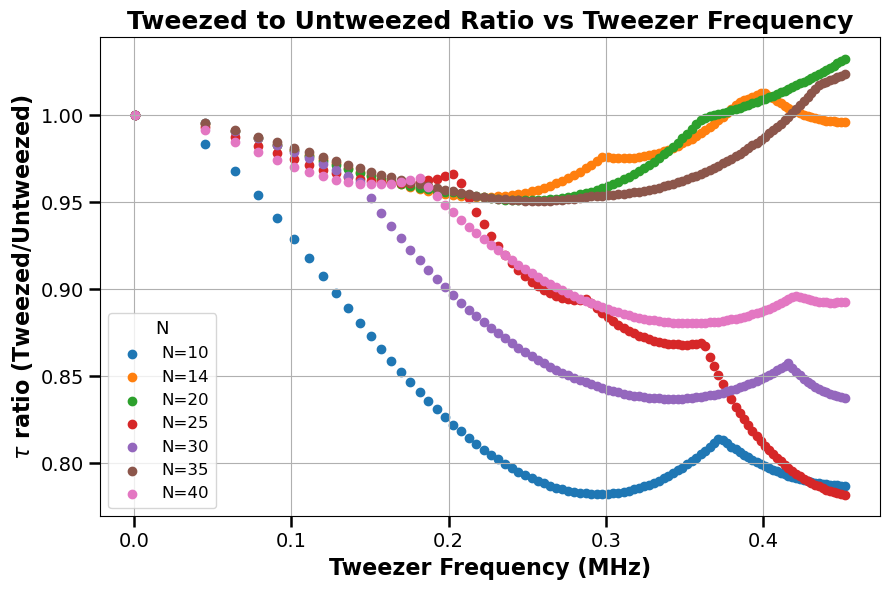

In [144]:
# Sweep power and plot tweezed/untweezed ratio vs tweezer frequency
w0 = 1e-6
f_rf_a = 300e3
Ns_to_plot = [10,14,20,25,30,35,40]

# Build ueq_equally_spaced for all N values
w_rf_a = f_rf_a * 2 * np.pi
ueq_equally_spaced = {N: equally_spaced_positions(N, ion_spacing(N, w_rf_a)[0][1] - ion_spacing(N, w_rf_a)[0][0]) for N in Ns_to_plot}

# precompute f_rf_r for each N
f_rf_r_by_N = {Nval: (0.77 * Nval * f_rf_a * 2) / np.log(Nval) for Nval in Ns_to_plot}
print(np.array(list(f_rf_r_by_N.values())) / 1e6, "MHz")

power_values = np.linspace(1e-6, 200e-3, 100)

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}
tweezer_freqs = {N: [] for N in Ns_to_plot}  # Store tweezer frequencies

for p in power_values:
    P_current = [p]

    # Calculate tweezer frequency for this power (same for all N for given p)
    tweezer_freq = omega_tweezer_r(
        potential(omega_tweezer, linewidths, omega_res, p, w0),
        w0, m
    )

    for N_fixed in Ns_to_plot:
        f_rf_r_local = f_rf_r_by_N[N_fixed]

        # tweezed
        test_loop = midcircuit_modes(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r_local, ueq_equally_spaced, P_current, w0
        )
        dfs = []
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            dfs = [df]

        # untweezed
        test_loop_u = midcircuit_modes_untweezed(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r_local, ueq_equally_spaced, P_current, w0
        )
        dfs_untweezed = []
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            dfs_untweezed = [dfu]

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) or np.isnan(val_u) or val_u == 0) else (val_t / val_u)

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)
        tweezer_freqs[N_fixed].append(tweezer_freq)  # Store frequency for this N

# --- Plot: ratio curves vs tweezer frequency ---
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10.colors

for i, N_fixed in enumerate(Ns_to_plot):
    # Convert frequencies to MHz for readability
    freqs_MHz = np.array(tweezer_freqs[N_fixed]) / (2 * np.pi * 1e6)
    ax.scatter(freqs_MHz, ratio_vals[N_fixed], marker='o',
               color=colors[i % len(colors)], label=f'N={N_fixed}')

ax.set_xlabel("Tweezer Frequency (MHz)", fontsize=16, fontweight='bold')
ax.set_ylabel(r"$\tau$ ratio (Tweezed/Untweezed)", fontsize=16, fontweight='bold')
ax.set_title("Tweezed to Untweezed Ratio vs Tweezer Frequency", fontsize=18, fontweight='bold')
ax.grid(True)
ax.legend(title="N", fontsize=12, title_fontsize=13)
ax.tick_params(axis='both', which='major', labelsize=14, length=8, width=1.8)
plt.tight_layout()
plt.show()


plot optimal power 

In [ ]:
# Example usage: Sweep power and find minima for N=3-31
power_values = np.linspace(1e-6, 200e-3, 100)
Ns_to_sweep = np.arange(3, 31)



results = sweep_power_and_find_minima(
    omega_tweezer, linewidths, omega_res, m, mode_calc_r,
    Ns_to_sweep, f_rf_r, ueq_dict, w0, power_values
)

# Access the results:
t_vals = results['t_vals']
u_vals = results['u_vals']
ratio_vals = results['ratio_vals']
min_power_indices = results['min_power_indices']

# Extract optimal powers for each N
optimal_powers = {N: min_power_indices[N][0] for N in Ns_to_sweep}

# Convert optimal powers to tweezer frequencies
optimal_freqs_MHz = {}
for N, power_mW in optimal_powers.items():
    power_W = power_mW / 1e3
    tweezer_freq = omega_tweezer_r(
        potential(omega_tweezer, linewidths, omega_res, power_W, w0),
        w0, m
    )
    optimal_freqs_MHz[N] = tweezer_freq / (2 * np.pi * 1e6)

# Print minima
print("Minimum ratio for each N:")
print("-" * 70)
for N in Ns_to_sweep:
    min_power, min_ratio = min_power_indices[N]
    opt_freq = optimal_freqs_MHz[N]
    print(f"N={N}: min ratio = {min_ratio:.6f} at power = {min_power:.4f} mW (freq = {opt_freq:.2f} MHz)")

print("\n")

# ============================================================
# Plot 1: Optimal tweezer frequency vs N
Ns_plot = np.array(list(optimal_freqs_MHz.keys()))
freqs_MHz_plot = np.array(list(optimal_freqs_MHz.values()))

plt.figure(figsize=(8, 5))
plt.scatter(Ns_plot, freqs_MHz_plot, marker='o', color='C0', s=50)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel("Optimal Tweezer Frequency (MHz)", fontsize=12)
plt.title("Optimal Tweezer Frequency vs Number of Ions", fontsize=14)
plt.grid(True)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: Ratio at optimal power vs N

# Convert optimal powers to watts for function call
optimal_powers_W = {N: p / 1e3 for N, p in optimal_powers.items()}

dfs = []
dfs_untweezed = []

# Iterate over N and use the optimal P value found for each N
for N in Ns_to_sweep:
    P = optimal_powers_W[N]
    P_current = [P]
    
    # Tweezed
    test_loop = midcircuit_modes(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N, f_rf_r, ueq_dict, P_current, w0
    )
    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        dfs.append(df)
    
    # Untweezed
    test_loop_u = midcircuit_modes_untweezed(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N, f_rf_r, ueq_dict, P_current, w0
    )
    if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
        dfu = test_loop_u.copy().reset_index(drop=True)
        dfu['N'] = int(N)
        dfs_untweezed.append(dfu)

# Combine DataFrames
combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

# Calculate the ratio of tweezed to untweezed
common_N = sorted(set(Ns_t).intersection(set(Ns_u)))
ratios = [vals_t[np.where(Ns_t == N)[0][0]] / vals_u[np.where(Ns_u == N)[0][0]] for N in common_N]

# Plot: Ratio at optimal power vs N
plt.figure(figsize=(8, 5))
plt.scatter(common_N, ratios, marker='o', color='green', s=50)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel(r"$\tau$ ratio (Tweezed/Untweezed)", fontsize=12)
plt.title("Tweezed/Untweezed Ratio at Optimal Power vs N", fontsize=14)
plt.grid(True)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# ============================================================
# Print summary table
print("N\tOptimal Freq (MHz)\tRatio at Optimal Power")
print("-" * 60)
for N in common_N:
    opt_freq = optimal_freqs_MHz[N]
    ratio_val = ratios[common_N.index(N)]
    print(f"{N}\t{opt_freq:.2f}\t\t\t{ratio_val:.6f}")

# ============================================================
# Plot 3: Tweezed Ion and Coolant Ion vs N

tweezed_ions = []
coolant_ions = []
Ns_with_data = []

# Extract tweezed and coolant ions from combined_df
for N in Ns_to_sweep:
    subset = combined_df[combined_df['N'] == N]
    if not subset.empty:
        first_row = subset.iloc[0]
        tweezed_ion = first_row['Tweezed Ion']
        coolant_ion = first_row['Coolant Ion']
        
        tweezed_ions.append(int(tweezed_ion) if not pd.isna(tweezed_ion) else np.nan)
        coolant_ions.append(int(coolant_ion) if not pd.isna(coolant_ion) else np.nan)
        Ns_with_data.append(N)

# Plot tweezed and coolant ions vs N
plt.figure(figsize=(8, 5))
plt.plot(Ns_with_data, tweezed_ions, marker='o', linestyle='-', color='C1', 
         label='Tweezed Ion', markersize=6)
plt.plot(Ns_with_data, coolant_ions, marker='s', linestyle='--', color='C0', 
         label='Coolant Ion', markersize=6)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel("Ion Index", fontsize=12)
plt.title("Tweezed and Coolant Ion Indices at Optimal Power vs N", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

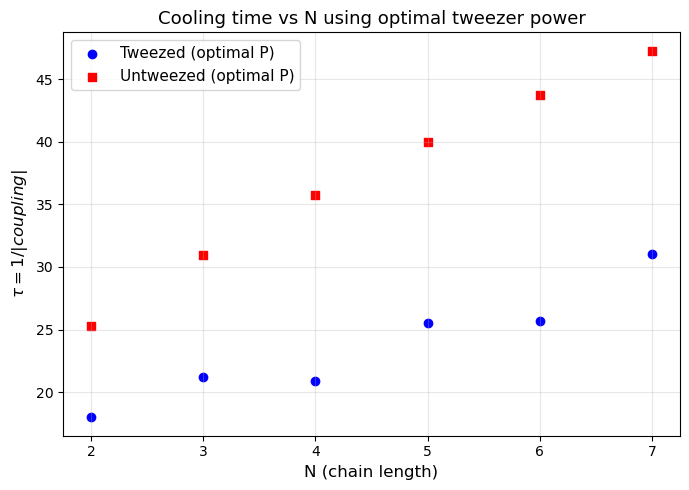

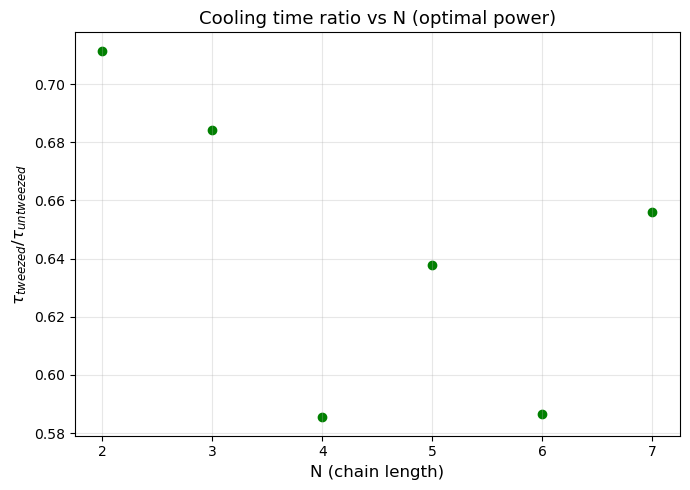

In [148]:
def _extract_score_from_winners(winners):
    if not winners:
        return np.nan
    win = winners[0]
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)):
        score_candidate = win[0][2] if len(win[0]) >= 3 else None
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score_candidate = win[2]
    else:
        score_candidate = None
    return abs(score_candidate) if score_candidate is not None else np.nan

N_vals = [entry[0] for entry in results_test_check]
scores_tweezed = [_extract_score_from_winners(entry[1]) for entry in results_test_check]
scores_untweezed = [_extract_score_from_winners(entry[1] if False else
                       [w for w in winners if isinstance(w, (list, tuple)) or isinstance(w, np.ndarray)]) for winners in [w for _, w in untweezed_results]]  # placeholder to keep alignment

tau_tweezed = np.array([1.0 / s if s not in (0, np.nan) and not np.isnan(s) else np.inf for s in scores_tweezed])
tau_untweezed = np.array([1.0 / s if s not in (0, np.nan) and not np.isnan(s) else np.inf for s in scores_untweezed])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(N_vals, tau_tweezed, marker='o', color='blue', label='Tweezed (optimal P)')
ax.scatter(N_vals, tau_untweezed, marker='s', color='red', label='Untweezed (optimal P)')
ax.set_xlabel('N (chain length)', fontsize=12)
ax.set_ylabel(r'$\tau = 1/|coupling|$', fontsize=12)
ax.set_title('Cooling time vs N using optimal tweezer power', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ratio = np.divide(tau_tweezed, tau_untweezed, out=np.full_like(tau_tweezed, np.nan), where=(tau_untweezed != 0))
ax.scatter(N_vals, ratio, marker='o', color='green')
ax.set_xlabel('N (chain length)', fontsize=12)
ax.set_ylabel(r'$\tau_{tweezed} / \tau_{untweezed}$', fontsize=12)
ax.set_title('Cooling time ratio vs N (optimal power)', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:

def midcircuit_modes_test(omega_tweezer,
                     linewidths,
                     omega_res,
                     m,
                     mode_calc_r,
                     N,
                     f_rf_r,
                     ueq_dict,
                     P,
                     w0
                     ):
    """
    Inputs:
    omega_tweezer = optical tweezer beam angular frequency [2*Pi x Hz]
    linewidths = linewidth of the given resonant transition taken from NIST database in angular frequency units 
        (ex, S1/2 to P1/2 and S1/2 to P3/2 for 40Ca+) 
    omega_res = angular frequency of resonant transition, also based off NIST data [2*Pi x Hz]
    m = mass of ion [kg]
    mode_calc_r = function from above to calculate radial modes
    N_list = list of number of ions to loop over (can also be a single integer)
    f_rf_r = radial rf trapping frequency [Hz]
    ueq_dict = dictionary of equilibrium positions for each ion
    P_opt = list of total optical power of tweezer laser beam to loop over (can also be a single number) [W]
    w0 = beamwaist of the tweezer laser beam [m] 
    
    Returns:
    dataframe with columns:
    - "Tweezed Ion": which ion is tweezed in this configuration (NaN/None if no tweezed ion) (int)
    - "Coolant Ion": which ion is the best coolant candidate for this configuration (int)
    - "Mode couplings": array of mode coupling values for the coolant ion in this configuration (numpy array)
    - "inverse_mode_couplings": array of 1/abs(mode coupling) (numpy array)
    - "sum_inverse_middle": sum of the inverse_mode_couplings for this row (float)
    """
    # get all mode strucures for all possible tweezed ion positions
    results = tweezer_combos_full_radial(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq_dict,
        P,
        w0,
        max_tweezed=1,
    )
    # build the mode lists
    result = build_mode_series_and_combinations(results)
    mode_list_test = []
    # Get all mode indices (0 to N-1) and append them in order
    mode_indices = sorted(result["mode_lists"].keys())
    for i in mode_indices:
        mode_list_test.append(result["mode_lists"][i])

    # make a data frame for the all modes from one ion across every ion for every tweezer configuration
    middle = combine_lists_same_index_df(*mode_list_test)

    # Filter the dataframe to pick only the best ion to cool and the best ion to tweeze 
    best_rows = middle.iloc[0:0].copy()
    tweezed_keys = [k for k in middle["Tweezed Ion"].unique() if pd.notna(k)]

    for key in tweezed_keys:
        subset = middle[middle["Tweezed Ion"] == key]
        if subset.empty:
            continue
        
        # First, considering Coolant Ion == Tweezed Ion and finding the smallest sum_inverse_middle
        subset_same = subset[subset["Coolant Ion"] == key]
        if not subset_same.empty:
            mn_same = subset_same["sum_inverse_middle"].abs().min()
            mask_same = np.isclose(subset_same["sum_inverse_middle"].abs(), mn_same, rtol=1e-12, atol=1e-12)
            tied_same = subset_same.loc[mask_same]
            chosen_same = tied_same.sort_values("Coolant Ion", na_position="last").iloc[0:1]
            best_rows = pd.concat([best_rows, chosen_same], ignore_index=True)
        
    # Pick the winner across both cases, lowest sum_inverse_middle
    if best_rows.empty:
        return best_rows

    global_min = best_rows["sum_inverse_middle"].abs().min()
    keep_mask = np.isclose(best_rows["sum_inverse_middle"].abs(), global_min, rtol=1e-8, atol=1e-12)
    final = best_rows.loc[keep_mask].reset_index(drop=True)

    return final

In [6]:
# Sweep power and plot tweezed/untweezed ratio vs tweezer frequency
w0 = 1e-6
f_rf_a = 100e3
Ns_to_plot = [10,20,30,40,60,5,3]
d = 4e-6

# Build ueq_dict for all N values (harmonic oscillator positions)
w_rf_a = f_rf_a * 2 * np.pi
ueq_dict = {Nval: equally_spaced_positions(Nval,d) for Nval in Ns_to_plot}

# precompute f_rf_r for each N: f_rf_r/f_rf_a = 0.77 * N / sqrt(log(N))
#f_rf_r_by_N = {Nval: f_rf_a * 0.77 * Nval / np.sqrt(np.log(Nval)) for Nval in Ns_to_plot}
#print(np.array(list(f_rf_r_by_N.values())) / 1e6, "MHz")
f_rf_r_const = 3e6  # Hz (pick whatever constant you want)
f_rf_r_by_N = {Nval: f_rf_r_const for Nval in range(3, 101)}

power_values = np.linspace(1e-6, 1000e-3, 100) # in Watts

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}
tweezer_freqs = {N: [] for N in Ns_to_plot}  # Store tweezer frequencies

for p in power_values:
    P_current = [p]

    # Calculate tweezer frequency for this power (same for all N for given p)
    tweezer_freq = omega_tweezer_r(
        potential(omega_tweezer, linewidths, omega_res, p, w0),
        w0, m
    )
    #print(tweezer_freq)

    for N_fixed in Ns_to_plot:
        f_rf_r_local = f_rf_r_by_N[N_fixed]

        # tweezed
        test_loop = midcircuit_modes_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r_local, ueq_dict, P_current, w0
        )
        dfs = []
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            dfs = [df]

        # untweezed
        test_loop_u = midcircuit_modes_untweezed(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r_local, ueq_dict, P_current, w0
        )
        dfs_untweezed = []
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            dfs_untweezed = [dfu]

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) or np.isnan(val_u) or val_u == 0) else (val_t / val_u)

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)
        tweezer_freqs[N_fixed].append(tweezer_freq)  # Store frequency for this N






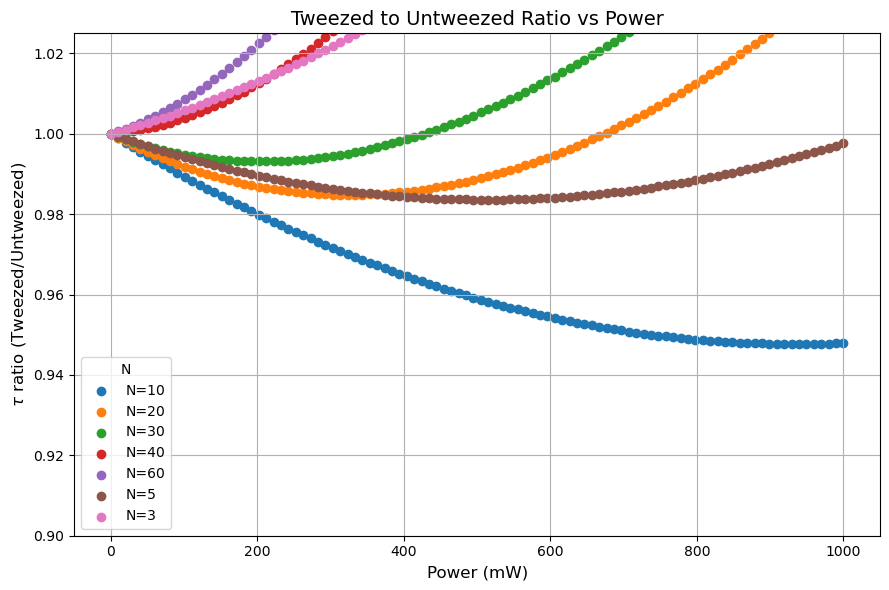

In [10]:
# --- Plot: ratio curves vs tweezer frequency ---
plt.figure(figsize=(9, 6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    # Convert frequencies to MHz for readability
    freqs_MHz = np.array(tweezer_freqs[N_fixed]) / (2 * np.pi*1e6)
    plt.scatter(power_values*1e3, ratio_vals[N_fixed], marker='o',
                color=colors[i % len(colors)], label=f'N={N_fixed}')

plt.xlabel("Power (mW)", fontsize=12)
plt.ylabel(r"$\tau$ ratio (Tweezed/Untweezed)", fontsize=12)
plt.ylim(0.90,1.025)
plt.title("Tweezed to Untweezed Ratio vs Power", fontsize=14)
plt.grid(True)
plt.legend(title="N")
plt.tight_layout()
plt.show()

In [11]:
def sweep_power_and_find_minima_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    Ns_to_sweep,
    f_rf_r,
    ueq_dict,
    w0,
    power_values,
):
    """
    Sweep power values for given N values and find minimum tweezed/untweezed ratio.
    
    Parameters:
    -----------
    omega_tweezer, linewidths, omega_res, m, mode_calc_r : system parameters
    Ns_to_sweep : list of N values to evaluate
    f_rf_r, ueq_dict, w0 : RF and tweezer parameters
    power_values : array of power values (in watts) to sweep
    
    Returns:
    --------
    Dictionary with keys:
        't_vals': dict mapping N to list of tweezed metric values
        'u_vals': dict mapping N to list of untweezed metric values
        'ratio_vals': dict mapping N to list of ratio values
        'min_power_indices': dict mapping N to (min_power_mW, min_ratio)
        'power_values': the input power array for reference
    """
    
    def first_sum_by_N(df):
        if df is None or df.empty:
            return np.array([]), np.array([])
        first = df.groupby("N", sort=True, as_index=False).first()
        return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()
    
    t_vals = {N: [] for N in Ns_to_sweep}
    u_vals = {N: [] for N in Ns_to_sweep}
    ratio_vals = {N: [] for N in Ns_to_sweep}
    
    for p in power_values:
        P_current = [p]
        for N_fixed in Ns_to_sweep:
            # tweezed
            test_loop = midcircuit_modes_test(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, ueq_dict, P_current, w0
            )
            dfs = []
            if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
                df = test_loop.copy().reset_index(drop=True)
                df['N'] = int(N_fixed)
                dfs = [df]
            
            # untweezed
            test_loop_u = midcircuit_modes_untweezed(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, ueq_dict, P_current, w0
            )
            dfs_untweezed = []
            if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
                dfu = test_loop_u.copy().reset_index(drop=True)
                dfu['N'] = int(N_fixed)
                dfs_untweezed = [dfu]
            
            combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
            combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()
            
            _, vals_t_arr = first_sum_by_N(combined_df)
            _, vals_u_arr = first_sum_by_N(combined_untweezed)
            
            val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
            val_u = vals_u_arr[0] if vals_u_arr.size else np.nan
            
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = np.nan if (np.isnan(val_t) or np.isnan(val_u) or val_u == 0) else (val_t / val_u)
            
            t_vals[N_fixed].append(val_t)
            u_vals[N_fixed].append(val_u)
            ratio_vals[N_fixed].append(ratio)
    
    # Find minimum ratio for each N
    min_power_indices = {}
    for N_fixed in Ns_to_sweep:
        ratio_list = ratio_vals[N_fixed]
        min_ratio = np.nanmin(ratio_list)
        min_idx = np.nanargmin(ratio_list)
        min_power_mW = power_values[min_idx] * 1e3
        min_power_indices[N_fixed] = (min_power_mW, min_ratio)
    
    return {
        't_vals': t_vals,
        'u_vals': u_vals,
        'ratio_vals': ratio_vals,
        'min_power_indices': min_power_indices,
        'power_values': power_values,
    }


Minimum ratio for each N:
----------------------------------------------------------------------
N=3: min ratio = 1.000000 at power = 0.0010 mW (freq = 0.00 MHz)
N=4: min ratio = 1.000000 at power = 0.0010 mW (freq = 0.00 MHz)
N=5: min ratio = 0.983609 at power = 515.1520 mW (freq = 0.72 MHz)
N=6: min ratio = 0.963594 at power = 828.2830 mW (freq = 0.92 MHz)
N=7: min ratio = 1.000000 at power = 0.0010 mW (freq = 0.00 MHz)
N=8: min ratio = 0.980374 at power = 494.9500 mW (freq = 0.71 MHz)
N=9: min ratio = 0.972652 at power = 616.1620 mW (freq = 0.79 MHz)
N=10: min ratio = 0.947703 at power = 939.3940 mW (freq = 0.98 MHz)
N=11: min ratio = 0.981081 at power = 444.4450 mW (freq = 0.67 MHz)
N=12: min ratio = 0.943129 at power = 949.4950 mW (freq = 0.98 MHz)
N=13: min ratio = 0.999837 at power = 40.4050 mW (freq = 0.20 MHz)
N=14: min ratio = 0.982366 at power = 393.9400 mW (freq = 0.63 MHz)
N=15: min ratio = 1.000000 at power = 0.0010 mW (freq = 0.00 MHz)
N=16: min ratio = 0.989229 at power

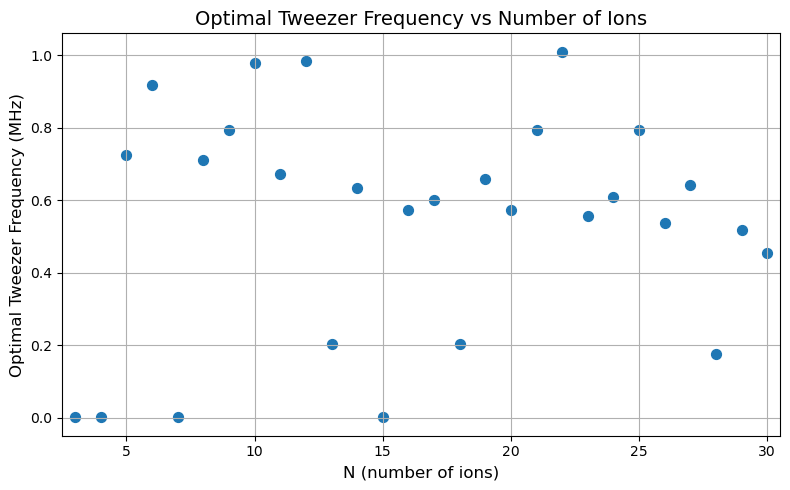

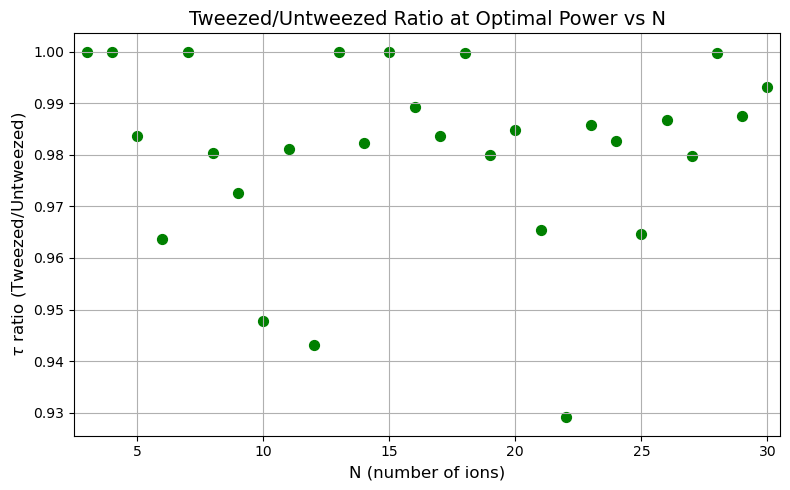

N	Optimal Freq (MHz)	Ratio at Optimal Power
------------------------------------------------------------
3	0.00			1.000000
4	0.00			1.000000
5	0.72			0.983609
6	0.92			0.963594
7	0.00			1.000000
8	0.71			0.980374
9	0.79			0.972652
10	0.98			0.947703
11	0.67			0.981081
12	0.98			0.943129
13	0.20			0.999837
14	0.63			0.982366
15	0.00			1.000000
16	0.57			0.989229
17	0.60			0.983654
18	0.20			0.999803
19	0.66			0.979994
20	0.57			0.984806
21	0.79			0.965428
22	1.01			0.929080
23	0.56			0.985816
24	0.61			0.982642
25	0.79			0.964585
26	0.54			0.986698
27	0.64			0.979716
28	0.18			0.999828
29	0.52			0.987466
30	0.45			0.993116
31	0.30			0.998517
32	0.50			0.988143
33	0.14			0.999853
34	0.54			0.986271
35	0.49			0.988745
36	1.01			0.999805
37	0.42			0.994189
38	0.48			0.989283
39	0.51			0.987558
40	0.00			1.000000


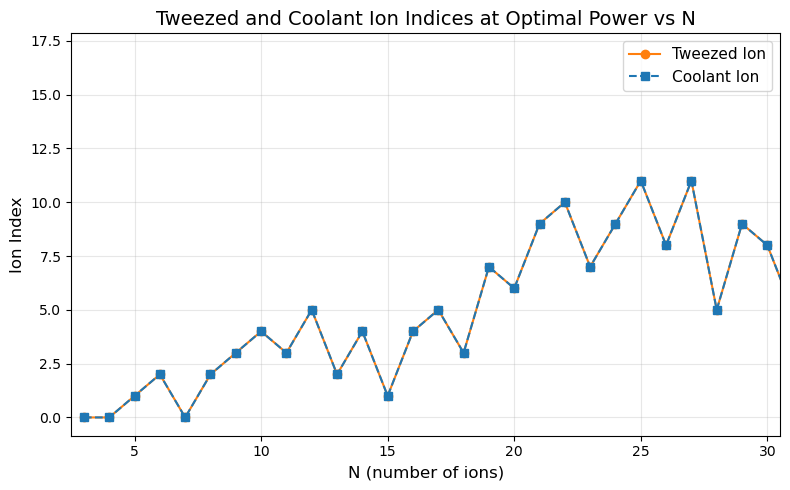

In [14]:
# Example usage: Sweep power and find minima for N=3-51
power_values = np.linspace(1e-6, 1000e-3, 100)
Ns_to_sweep = np.arange(3, 41)

# Build ueq_dict for all N values
w_rf_a = f_rf_a * 2 * np.pi
f_rf_r = 3e6  # Hz (pick whatever constant you want)

ueq_dict = {Nval: equally_spaced_positions(Nval,d) for Nval in Ns_to_sweep}

results = sweep_power_and_find_minima_test(
    omega_tweezer, linewidths, omega_res, m, mode_calc_r,
    Ns_to_sweep, f_rf_r, ueq_dict, w0, power_values
)

# Access the results:
t_vals = results['t_vals']
u_vals = results['u_vals']
ratio_vals = results['ratio_vals']
min_power_indices = results['min_power_indices']

# Extract optimal powers for each N
optimal_powers = {N: min_power_indices[N][0] for N in Ns_to_sweep}

# Convert optimal powers to tweezer frequencies
optimal_freqs_MHz = {}
for N, power_mW in optimal_powers.items():
    power_W = power_mW / 1e3
    tweezer_freq = omega_tweezer_r(
        potential(omega_tweezer, linewidths, omega_res, power_W, w0),
        w0, m
    )
    optimal_freqs_MHz[N] = tweezer_freq / (2 * np.pi * 1e6)

# Print minima
print("Minimum ratio for each N:")
print("-" * 70)
for N in Ns_to_sweep:
    min_power, min_ratio = min_power_indices[N]
    opt_freq = optimal_freqs_MHz[N]
    print(f"N={N}: min ratio = {min_ratio:.6f} at power = {min_power:.4f} mW (freq = {opt_freq:.2f} MHz)")
print("\n")

# ============================================================
# Plot 1: Optimal tweezer frequency vs N
Ns_plot = np.array(list(optimal_freqs_MHz.keys()))
freqs_MHz_plot = np.array(list(optimal_freqs_MHz.values()))

plt.figure(figsize=(8, 5))
plt.scatter(Ns_plot, freqs_MHz_plot, marker='o', color='C0', s=50)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel("Optimal Tweezer Frequency (MHz)", fontsize=12)
plt.title("Optimal Tweezer Frequency vs Number of Ions", fontsize=14)
plt.grid(True)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: Ratio at optimal power vs N

# Convert optimal powers to watts for function call
optimal_powers_W = {N: p / 1e3 for N, p in optimal_powers.items()}

dfs = []
dfs_untweezed = []

# Iterate over N and use the optimal P value found for each N
for N in Ns_to_sweep:
    P = optimal_powers_W[N]
    P_current = [P]
    
    # Tweezed
    test_loop = midcircuit_modes_test(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N, f_rf_r, ueq_dict, P_current, w0
    )
    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        dfs.append(df)
    
    # Untweezed
    test_loop_u = midcircuit_modes_untweezed(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N, f_rf_r, ueq_dict, P_current, w0
    )
    if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
        dfu = test_loop_u.copy().reset_index(drop=True)
        dfu['N'] = int(N)
        dfs_untweezed.append(dfu)

# Combine DataFrames
combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

# Calculate the ratio of tweezed to untweezed
common_N = sorted(set(Ns_t).intersection(set(Ns_u)))
ratios = [vals_t[np.where(Ns_t == N)[0][0]] / vals_u[np.where(Ns_u == N)[0][0]] for N in common_N]

# Plot: Ratio at optimal power vs N
plt.figure(figsize=(8, 5))
plt.scatter(common_N, ratios, marker='o', color='green', s=50)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel(r"$\tau$ ratio (Tweezed/Untweezed)", fontsize=12)
plt.title("Tweezed/Untweezed Ratio at Optimal Power vs N", fontsize=14)
plt.grid(True)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# ============================================================
# Print summary table
print("N\tOptimal Freq (MHz)\tRatio at Optimal Power")
print("-" * 60)
for N in common_N:
    opt_freq = optimal_freqs_MHz[N]
    ratio_val = ratios[common_N.index(N)]
    print(f"{N}\t{opt_freq:.2f}\t\t\t{ratio_val:.6f}")

# ============================================================
# Plot 3: Tweezed Ion and Coolant Ion vs N

tweezed_ions = []
coolant_ions = []
Ns_with_data = []

# Extract tweezed and coolant ions from combined_df
for N in Ns_to_sweep:
    subset = combined_df[combined_df['N'] == N]
    if not subset.empty:
        first_row = subset.iloc[0]
        tweezed_ion = first_row['Tweezed Ion']
        coolant_ion = first_row['Coolant Ion']
        
        tweezed_ions.append(int(tweezed_ion) if not pd.isna(tweezed_ion) else np.nan)
        coolant_ions.append(int(coolant_ion) if not pd.isna(coolant_ion) else np.nan)
        Ns_with_data.append(N)

# Plot tweezed and coolant ions vs N
plt.figure(figsize=(8, 5))
plt.plot(Ns_with_data, tweezed_ions, marker='o', linestyle='-', color='C1', 
         label='Tweezed Ion', markersize=6)
plt.plot(Ns_with_data, coolant_ions, marker='s', linestyle='--', color='C0', 
         label='Coolant Ion', markersize=6)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel("Ion Index", fontsize=12)
plt.title("Tweezed and Coolant Ion Indices at Optimal Power vs N", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()